In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [3]:
# Reload dataset
df = pd.read_csv("household_power_consumption.txt", sep=";", low_memory=False)
df.head(5)

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [4]:
# Replace '?' with NaN
df.replace("?", np.nan, inplace=True)

In [5]:
df.sample()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
779175,9/6/2008,19:39:00,1.692,0.316,237.870,7.200,0.000,2.000,18.0


In [6]:
# Convert numeric columns
for col in df.columns:
    if col not in ["Date", "Time"]:
        df[col] = df[col].astype(float)

In [7]:



# Forward fill missing values
df.fillna(method="ffill", inplace=True)

In [8]:
# Create Datetime column
df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H:%M:%S"
)


In [9]:
df.columns


Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3', 'Datetime'],
      dtype='object')

In [10]:
# Set index
df.set_index("Datetime", inplace=True)

In [11]:
# Drop Date and Time columns
df.drop(["Date", "Time"], axis=1, inplace=True)

In [12]:
# Remove duplicate timestamps
df = df[~df.index.duplicated(keep="first")]

In [13]:
# Resample to hourly
df_hourly = df.resample("H").mean()

In [14]:
df_hourly.columns


Index(['Global_active_power', 'Global_reactive_power', 'Voltage',
       'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')

In [15]:
TARGET = "Global_active_power"

df_fe = df_hourly.copy()


In [16]:
df_fe["hour"] = df_fe.index.hour
df_fe["day"] = df_fe.index.day
df_fe["dayofweek"] = df_fe.index.dayofweek
df_fe["month"] = df_fe.index.month


In [17]:
df_fe["lag_1"] = df_fe[TARGET].shift(1)
df_fe["lag_24"] = df_fe[TARGET].shift(24)
df_fe["lag_168"] = df_fe[TARGET].shift(168)


In [18]:
df_fe["rolling_mean_24"] = (
    df_fe[TARGET]
    .rolling(window=24)
    .mean()
    .shift(1)
)

df_fe["rolling_std_24"] = (
    df_fe[TARGET]
    .rolling(window=24)
    .std()
    .shift(1)
)
df_fe['is_peak'] = df_fe['hour'].apply(lambda x: 1 if 17 <= x <= 21 else 0)

In [19]:
df_fe.dropna(inplace=True)


In [20]:
df_fe.head()


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,day,dayofweek,month,lag_1,lag_24,lag_168,rolling_mean_24,rolling_std_24,is_peak
Datetime,,,,,,,,,,,,,,,,,
2006-12-23 17:00:00,5.452533,0.215967,233.644167,23.360000,16.183333,0.666667,16.750000,17,23,5,12,4.349100,1.496800,4.222889,2.934890,0.990187,1
2006-12-23 18:00:00,3.879400,0.099767,238.000500,16.363333,0.000000,0.016667,17.350000,18,23,5,12,5.452533,2.686967,3.632200,3.099713,1.066674,1
2006-12-23 19:00:00,4.117833,0.205333,238.729333,17.300000,0.000000,0.600000,17.466667,19,23,5,12,3.879400,3.938167,3.400233,3.149397,1.074356,1
2006-12-23 20:00:00,4.181400,0.124767,238.518833,17.596667,0.000000,0.350000,17.416667,20,23,5,12,4.117833,3.536067,3.268567,3.156883,1.080699,1
2006-12-23 21:00:00,3.288433,0.235767,238.594667,13.893333,0.000000,0.216667,5.666667,21,23,5,12,4.181400,4.548667,3.056467,3.183772,1.098426,1


In [21]:
df_fe.info()
df_fe.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 34421 entries, 2006-12-23 17:00:00 to 2010-11-26 21:00:00
Freq: H
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Global_active_power    34421 non-null  float64
 1   Global_reactive_power  34421 non-null  float64
 2   Voltage                34421 non-null  float64
 3   Global_intensity       34421 non-null  float64
 4   Sub_metering_1         34421 non-null  float64
 5   Sub_metering_2         34421 non-null  float64
 6   Sub_metering_3         34421 non-null  float64
 7   hour                   34421 non-null  int32  
 8   day                    34421 non-null  int32  
 9   dayofweek              34421 non-null  int32  
 10  month                  34421 non-null  int32  
 11  lag_1                  34421 non-null  float64
 12  lag_24                 34421 non-null  float64
 13  lag_168                34421 non-null  float64
 14  rolling_mea

Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
hour                     0
day                      0
dayofweek                0
month                    0
lag_1                    0
lag_24                   0
lag_168                  0
rolling_mean_24          0
rolling_std_24           0
is_peak                  0
dtype: int64

In [22]:
target_variable = "Global_active_power"

cols_to_drop = [
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

X = df_fe.drop(columns=cols_to_drop + [target_variable])
y = df_fe[target_variable]


In [23]:
df_hourly.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 34589 entries, 2006-12-16 17:00:00 to 2010-11-26 21:00:00
Freq: H
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Global_active_power    34589 non-null  float64
 1   Global_reactive_power  34589 non-null  float64
 2   Voltage                34589 non-null  float64
 3   Global_intensity       34589 non-null  float64
 4   Sub_metering_1         34589 non-null  float64
 5   Sub_metering_2         34589 non-null  float64
 6   Sub_metering_3         34589 non-null  float64
dtypes: float64(7)
memory usage: 2.1 MB


In [24]:
df_hourly.describe()


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,34589.000000,34589.000000,34589.000000,34589.000000,34589.000000,34589.000000,34589.000000
mean,1.086200,0.123326,240.841505,4.604360,1.110951,1.287914,6.416515
std,0.894942,0.067221,2.999127,3.746337,3.518498,4.168720,7.344718
min,0.124000,0.000000,225.834500,0.503333,0.000000,0.000000,0.000000
25%,0.341267,0.077667,239.197167,1.510000,0.000000,0.000000,0.650000
50%,0.799533,0.106767,240.984500,3.406667,0.000000,0.333333,1.650000
75%,1.574967,0.149367,242.691833,6.583333,0.000000,0.650000,14.083333
max,6.560533,0.774333,251.902000,28.383333,48.366667,46.433333,21.550000


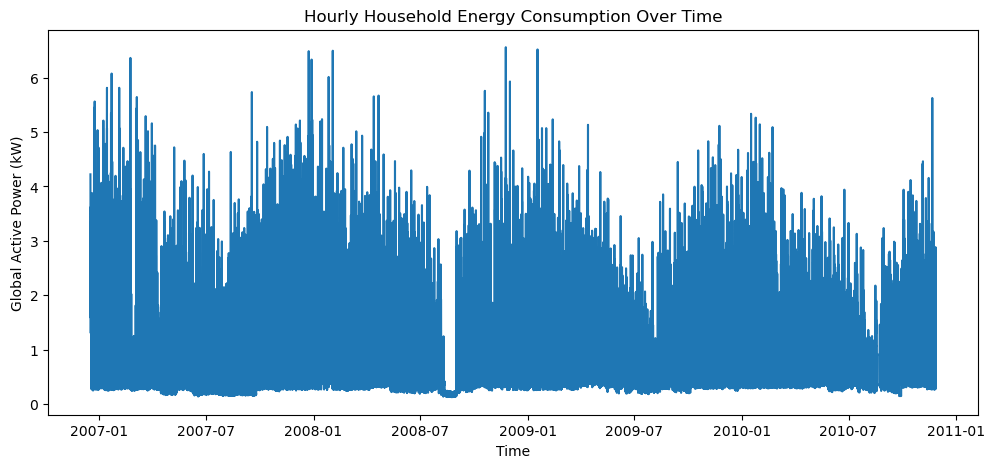

In [25]:
#Line graph

plt.figure(figsize=(12, 5))
plt.plot(df_hourly.index, df_hourly["Global_active_power"])
plt.title("Hourly Household Energy Consumption Over Time")
plt.xlabel("Time")
plt.ylabel("Global Active Power (kW)")
plt.show()








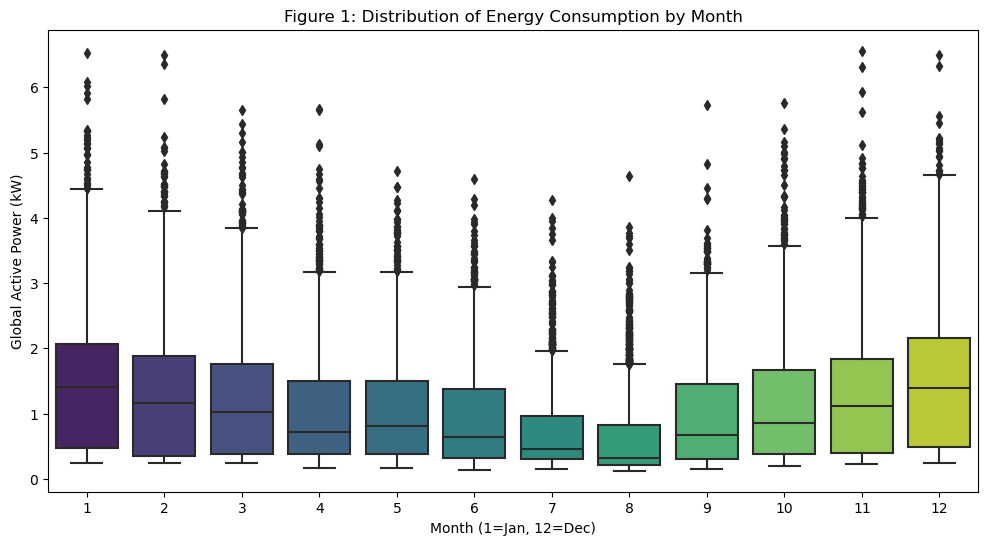

In [26]:
#(Box Plot)

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_hourly, x=df_hourly.index.month, y='Global_active_power', palette='viridis')
plt.title('Figure 1: Distribution of Energy Consumption by Month')
plt.xlabel('Month (1=Jan, 12=Dec)')
plt.ylabel('Global Active Power (kW)')
plt.show()


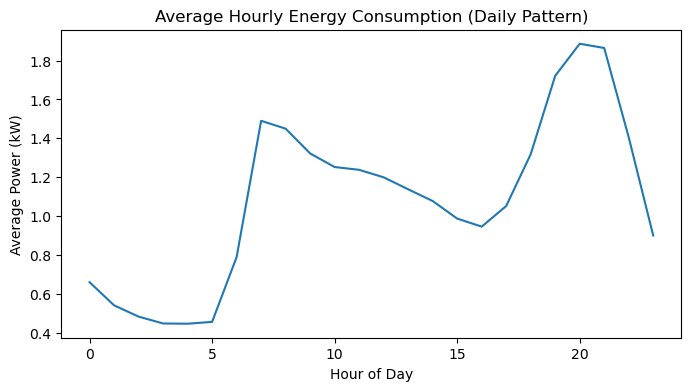

In [27]:
hourly_avg = df_hourly.groupby(df_hourly.index.hour)["Global_active_power"].mean()

plt.figure(figsize=(8, 4))
plt.plot(hourly_avg.index, hourly_avg.values)
plt.title("Average Hourly Energy Consumption (Daily Pattern)")
plt.xlabel("Hour of Day")
plt.ylabel("Average Power (kW)")
plt.show()


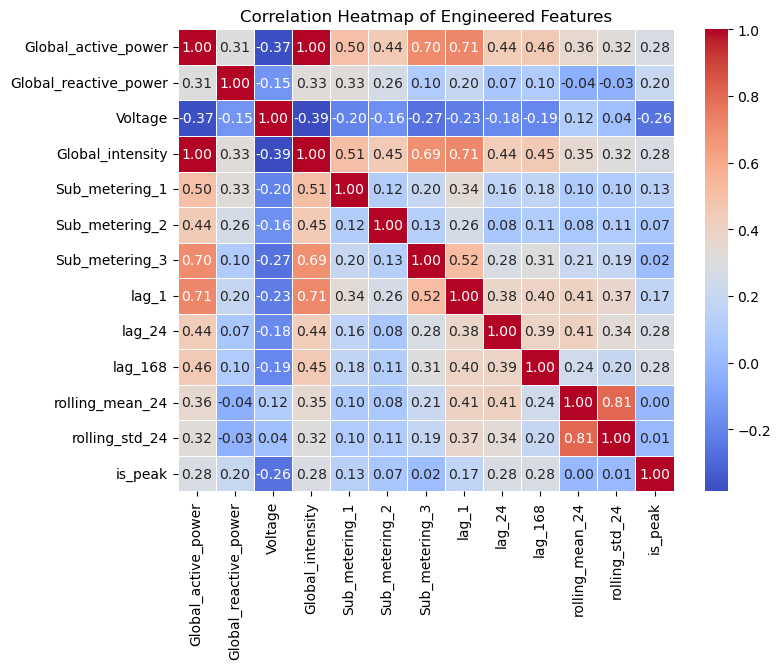

Global_active_power      1.000000
Global_intensity         0.999411
lag_1                    0.713876
Sub_metering_3           0.697252
Sub_metering_1           0.499417
lag_168                  0.455554
Sub_metering_2           0.442283
lag_24                   0.437113
rolling_mean_24          0.359464
rolling_std_24           0.321340
Global_reactive_power    0.309955
is_peak                  0.275846
Voltage                 -0.372617
Name: Global_active_power, dtype: float64


In [28]:
numeric_df = df_fe.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=True,        
    fmt=".2f",         
    linewidths=0.5
)
plt.title("Correlation Heatmap of Engineered Features")
plt.show()

target_corr = corr_matrix["Global_active_power"].sort_values(ascending=False)
print(target_corr)





In [29]:
split_index = int(len(df_fe) * 0.8)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]


In [30]:
print("Train shape:", X_train.shape, y_train.shape)
print("Test shape :", X_test.shape, y_test.shape)


Train shape: (27536, 10) (27536,)
Test shape : (6885, 10) (6885,)


In [31]:
from sklearn.preprocessing import MinMaxScaler
# 1. Create the scaler object
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [32]:

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = mean_squared_error(y_test, y_pred_lr, squared=False)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance:")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R2  :", r2_lr)



Linear Regression Performance:
MAE : 0.3626695342518923
RMSE: 0.5095039362395769
R2  : 0.513636905136766


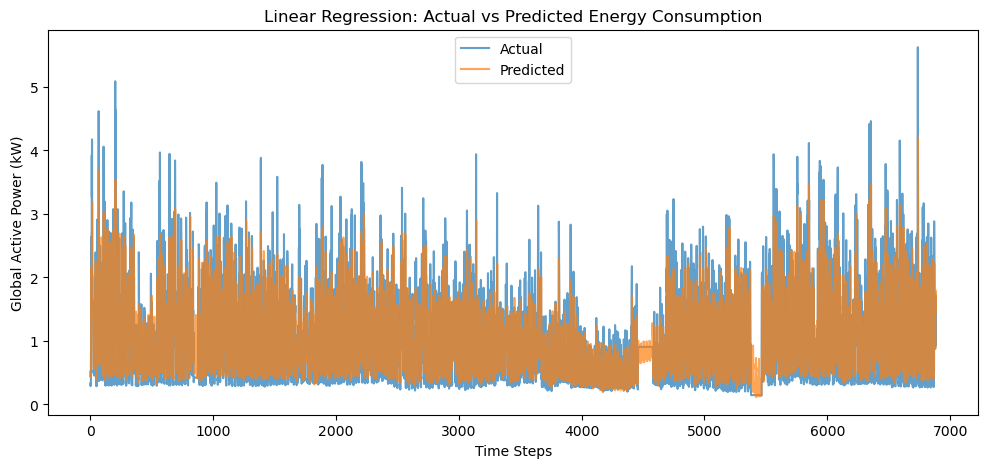

In [33]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label="Actual", alpha=0.7)
plt.plot(y_pred_lr, label="Predicted", alpha=0.7)
plt.title("Linear Regression: Actual vs Predicted Energy Consumption")
plt.xlabel("Time Steps")
plt.ylabel("Global Active Power (kW)")
plt.legend()
plt.show()


In [34]:
df_fe[[ "Global_active_power", "lag_1" ]].corr()


,Global_active_power,lag_1
Global_active_power,1.000000,0.713876
lag_1,0.713876,1.000000


In [35]:

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Random Forest (Time-only) Performance:
MAE : 0.33518416155894454
RMSE: 0.48257142453198537
R2  : 0.5636964673379842


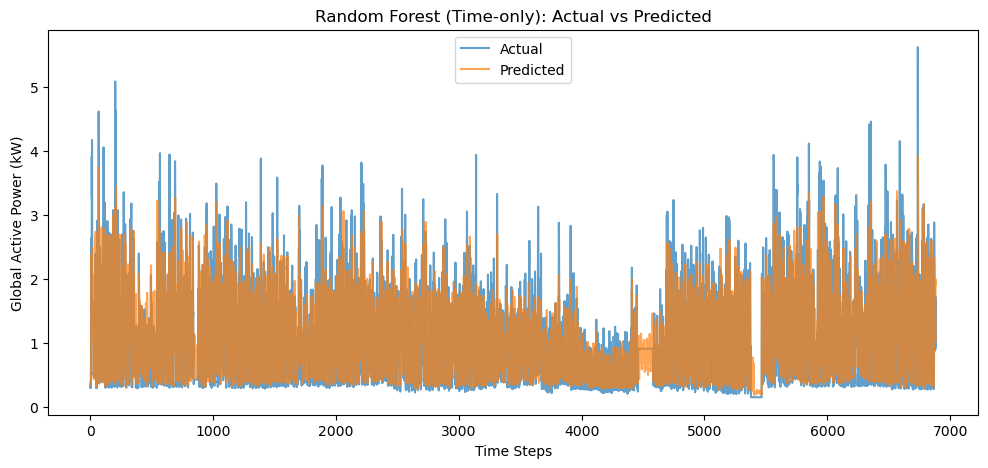

In [36]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# THIS LINE CREATES y_pred_rf
y_pred_rf = rf_model.predict(X_test)


# Metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = mean_squared_error(y_test, y_pred_rf, squared=False)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest (Time-only) Performance:")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R2  :", r2_rf)

# Plot
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label="Actual", alpha=0.7)
plt.plot(y_pred_rf, label="Predicted", alpha=0.7)
plt.title("Random Forest (Time-only): Actual vs Predicted")
plt.xlabel("Time Steps")
plt.ylabel("Global Active Power (kW)")
plt.legend()
plt.show()


In [37]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
# 1) Model (good default settings)
gbr_model = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# 2) Train
gbr_model.fit(X_train, y_train)

# 3) Predict
y_pred_gbr = gbr_model.predict(X_test)


Gradient Boosting Regressor Performance:
MAE : 0.3323426051261115
RMSE: 0.4772280125640384
R2  : 0.5733051682622066


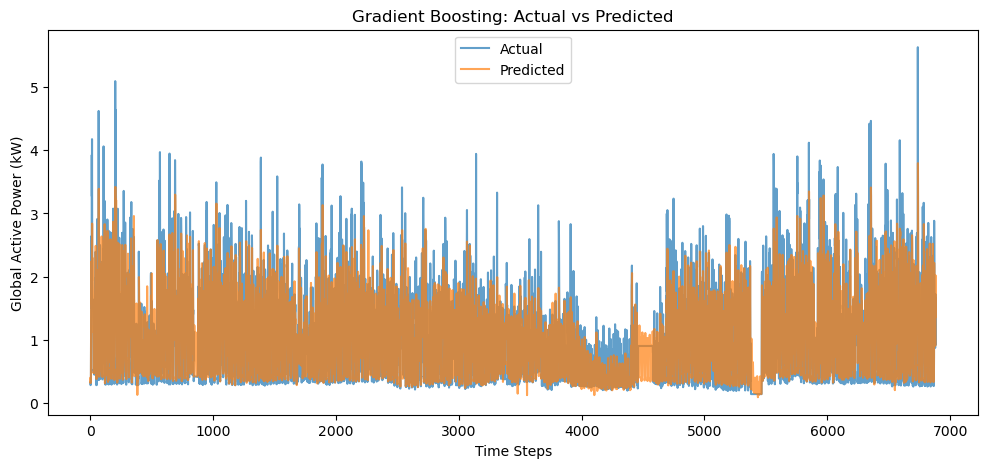

In [38]:
# 4) Metrics
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
rmse_gbr = mean_squared_error(y_test, y_pred_gbr, squared=False)
r2_gbr = r2_score(y_test, y_pred_gbr)

print("Gradient Boosting Regressor Performance:")
print("MAE :", mae_gbr)
print("RMSE:", rmse_gbr)
print("R2  :", r2_gbr)

# 5) Plot: Actual vs Predicted
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label="Actual", alpha=0.7)
plt.plot(y_pred_gbr, label="Predicted", alpha=0.7)
plt.title("Gradient Boosting: Actual vs Predicted")
plt.xlabel("Time Steps")
plt.ylabel("Global Active Power (kW)")
plt.legend()
plt.show()

In [39]:
pip install xgboost


Note: you may need to restart the kernel to use updated packages.


In [40]:
from xgboost import XGBRegressor
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)
# Train on SCALED data
xgb_model.fit(X_train_scaled, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)

In [41]:
y_pred_xgb = xgb_model.predict(X_test_scaled)


In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = mean_squared_error(y_test, y_pred_xgb, squared=False)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost (with MinMax Scaling) Performance:")
print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)
print("R2  :", r2_xgb)



XGBoost (with MinMax Scaling) Performance:
MAE : 0.327781318251465
RMSE: 0.4727493576783861
R2  : 0.5812764174216287


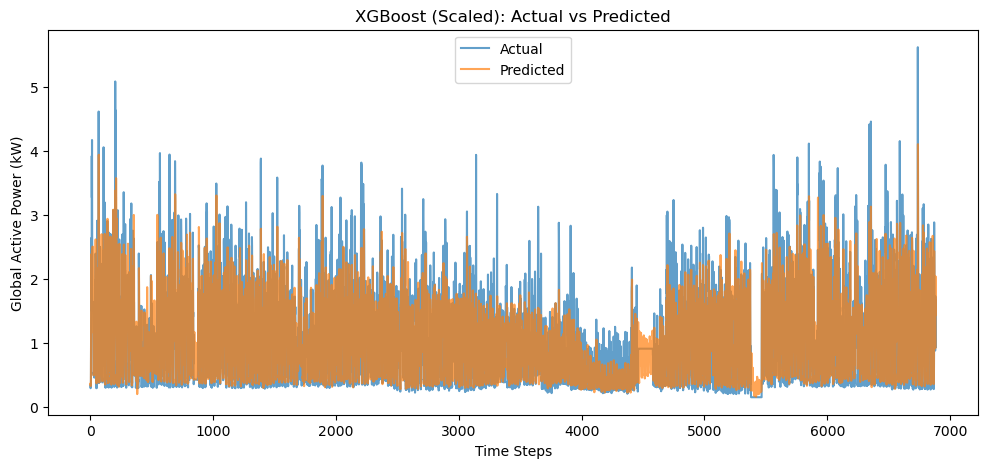

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label="Actual", alpha=0.7)
plt.plot(y_pred_xgb, label="Predicted", alpha=0.7)
plt.title("XGBoost (Scaled): Actual vs Predicted")
plt.xlabel("Time Steps")
plt.ylabel("Global Active Power (kW)")
plt.legend()
plt.show()


In [46]:
import pandas as pd

# Create a performance summary table
performance_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "MAE": [
        mae_lr,
        mae_rf,
        mae_gbr,
        mae_xgb
    ],
    "RMSE": [
        rmse_lr,
        rmse_rf,
        rmse_gbr,
        rmse_xgb
    ],
    "R2 Score": [
        r2_lr,
        r2_rf,
        r2_gbr,
        r2_xgb
    ]
})

# Display the table
performance_df


,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.362670,0.509504,0.513637
1,Random Forest,0.335184,0.482571,0.563696
2,Gradient Boosting,0.332343,0.477228,0.573305
3,XGBoost,0.327781,0.472749,0.581276
